# 10. Joint Optimization: REINFORCE for μ + Implicit Diff for γ

**Goal:** jointly optimize both the mean photon count (μ) and the Lorentzian HWHM (γ) by combining two gradient estimators:
- **REINFORCE** for μ (through the discrete rounding step)
- **Implicit differentiation** for γ (through the L-BFGS fit)
- **CRLB-based dσ/dγ** to also match the fit uncertainty distribution

**Algorithm version:** `with_dsigma` — the latest and most feature-complete.

In [1]:
import math, time, json, os
import numpy as np
import torch
from torch.autograd.functional import hessian, jacobian

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

torch.set_default_dtype(torch.float32)

FREQ_MIN, FREQ_MAX = -75.0, 75.0
UNIFORM_DENSITY = 1.0 / (FREQ_MAX - FREQ_MIN)
WIDTH_MAX, WIDTH_EPS = 150.0, 1e-2
print('Imports OK')

Imports OK


## Parameter & Model Definitions

In [2]:
# ---- Width mapping ----
def _w(r): return WIDTH_EPS + WIDTH_MAX * torch.sigmoid(r)
def _rw(w):
    f = max(min((w-WIDTH_EPS)/WIDTH_MAX, 1-1e-10), 1e-10)
    return math.log(f / (1-f))

# ---- Lorentzian + uniform model (3 params: center, raw_gamma, logit_w) ----
def _lor_log_pdf(f, c, rg, lw):
    g, w = _w(rg), torch.sigmoid(lw)
    hi, lo = torch.tensor(FREQ_MAX), torch.tensor(FREQ_MIN)
    lrz = (g/math.pi)/((f-c)**2+g**2)
    Zl = (torch.atan((hi-c)/g)-torch.atan((lo-c)/g))/math.pi
    sig = lrz/(Zl+1e-30)
    return torch.log(w*sig+(1-w)*UNIFORM_DENSITY+1e-30)

def _nll_lor(theta, photons):
    return -_lor_log_pdf(photons, theta[0], theta[1], theta[2]).mean()

def _lor_fwhm(theta):
    return 2.0 * _w(theta[1])

def _build_photons(gamma_val, u, b):
    half = 0.5 * (FREQ_MAX - FREQ_MIN)
    sig = gamma_val * np.tan(math.atan(half/gamma_val) * (2*u - 1))
    return np.concatenate([sig, b])

# ---- Implicit derivative: dFWHM/dgamma ----
def compute_sigma_only(gamma_val, u, b):
    n_sig, n_bg = len(u), len(b)
    if n_sig + n_bg < 3: return 0.5 * gamma_val
    photons_np = _build_photons(gamma_val, u, b)
    photons_t = torch.tensor(photons_np, dtype=torch.float32)
    theta = torch.tensor([float(photons_t.median()), _rw(15.0), 0.0], dtype=torch.float32, requires_grad=True)
    opt = torch.optim.LBFGS([theta], max_iter=80, line_search_fn='strong_wolfe')
    def closure():
        opt.zero_grad(); loss = _nll_lor(theta, photons_t); loss.backward(); return loss
    try: opt.step(closure)
    except: return 0.5 * gamma_val
    if not torch.isfinite(theta).all(): return 0.5 * gamma_val
    ts = theta.detach().clone().requires_grad_()
    loss_h = _nll_lor(ts, photons_t)
    gt = torch.autograd.grad(loss_h, ts, create_graph=True)[0]
    H = torch.zeros(3, 3, dtype=torch.float32)
    for i in range(3):
        gi = gt[i]
        for j in range(3):
            retain = not (i == 2 and j == 2)
            H[i, j] = torch.autograd.grad(gi, ts, retain_graph=retain)[0][j].detach()
    H_reg = H + 1e-4 * torch.eye(3)
    try: H_inv = torch.linalg.solve(H_reg, torch.eye(3))
    except: H_inv = torch.linalg.pinv(H_reg)
    tf = ts.detach().clone().requires_grad_()
    fw_at = _lor_fwhm(tf)
    dF = torch.autograd.grad(fw_at, tf)[0]
    sigma = torch.sqrt(((dF.unsqueeze(0) @ H_inv @ dF.unsqueeze(1)).squeeze().clamp_min(1e-30)) / max(len(photons_t), 1)).item()
    return sigma if math.isfinite(sigma) else 0.5 * gamma_val

def compute_fwhm_and_dgamma(gamma_val, u, b, reg=1e-4):
    n_sig, n_bg = len(u), len(b)
    if n_sig + n_bg < 3: return 2.0 * gamma_val, 0.5 * gamma_val, 2.0
    photons_np = _build_photons(gamma_val, u, b)
    photons_t = torch.tensor(photons_np, dtype=torch.float32)
    theta = torch.tensor([float(photons_t.median()), _rw(15.0), 0.0], dtype=torch.float32, requires_grad=True)
    opt = torch.optim.LBFGS([theta], max_iter=80, line_search_fn='strong_wolfe')
    def closure():
        opt.zero_grad(); loss = _nll_lor(theta, photons_t); loss.backward(); return loss
    try: opt.step(closure)
    except: return 2.0 * gamma_val, 0.5 * gamma_val, 2.0
    if not torch.isfinite(theta).all(): return 2.0 * gamma_val, 0.5 * gamma_val, 2.0
    theta_star = theta.detach().clone()
    fwhm_star = _lor_fwhm(theta.detach()).item()
    eps_g = 1e-3
    def _grad_theta_at_gamma(g_val):
        t = theta_star.detach().clone().requires_grad_()
        p = torch.tensor(_build_photons(g_val, u, b), dtype=torch.float32)
        return torch.autograd.grad(_nll_lor(t, p), t, create_graph=False)[0]
    grad_hi = _grad_theta_at_gamma(gamma_val + eps_g)
    grad_lo = _grad_theta_at_gamma(gamma_val - eps_g)
    H_theta_gamma = (grad_hi - grad_lo) / (2 * eps_g)
    t_for_hess = theta_star.detach().clone().requires_grad_()
    loss_for_hess = _nll_lor(t_for_hess, photons_t)
    H_theta_theta = torch.zeros(3, 3, dtype=torch.float32)
    grad_t = torch.autograd.grad(loss_for_hess, t_for_hess, create_graph=True)[0]
    for i in range(3):
        gi = grad_t[i]
        for j in range(3):
            H_theta_theta[i, j] = torch.autograd.grad(gi, t_for_hess, retain_graph=True, create_graph=False)[0][j].detach()
    t_for_df = theta_star.detach().clone().requires_grad_()
    fwhm_at_theta = _lor_fwhm(t_for_df)
    dF_dtheta = torch.autograd.grad(fwhm_at_theta, t_for_df, create_graph=False)[0]
    H_reg = H_theta_theta + reg * torch.eye(3)
    try: H_inv = torch.linalg.solve(H_reg, torch.eye(3))
    except: H_inv = torch.linalg.pinv(H_reg)
    df_dgamma = -(dF_dtheta.unsqueeze(0) @ H_inv @ H_theta_gamma.unsqueeze(1)).squeeze().item()
    if not math.isfinite(df_dgamma): df_dgamma = 2.0
    sigma_fwhm = torch.sqrt(((dF_dtheta.unsqueeze(0) @ H_inv @ dF_dtheta.unsqueeze(1)).squeeze().clamp_min(1e-30)) / max(len(photons_t), 1)).item()
    if not math.isfinite(sigma_fwhm): sigma_fwhm = 0.5 * gamma_val
    return fwhm_star, sigma_fwhm, df_dgamma

print('Model definitions OK')

Model definitions OK


## Parameters

| Param | Value | Meaning |
|---|---|---|
| NBAR_TRUE | 50 | True mean photon count |
| GAMMA_TRUE | 20 | True Lorentzian HWHM (MHz) |
| LAMBDA_ | 2 | Mean background counts per run |
| SIGMA_PROP | 12 | Proposal std for REINFORCE exploration |
| N_TARGET | 500 | Target FWHM runs to match against |
| N_RUNS | 300 | Simulated FWHM runs per iteration |
| N_ITER | 80 | Total optimization iterations |
| LR_MU | 15 | Learning rate for μ |
| LR_GAMMA | 0.5 | Learning rate for γ |
| MU_INIT | 8 | Initial μ guess |
| GAMMA_INIT | 5 | Initial γ guess |

In [3]:
GAMMA_TRUE = 20.0
NBAR_TRUE = 50.0
LAMBDA_ = 2.0
SIGMA_PROP = 12.0

N_TARGET = 500
N_RUNS = 300
N_ITER = 80

LR_MU = 15.0
LR_GAMMA = 0.5
BASELINE_ALPHA = 0.05
CLIP = 10.0
LAMBDA_SIGMA = 0.3
LAMBDA_GAMMA = 2.0

MU_INIT = 8.0
GAMMA_INIT = 5.0
SEED = 42
PLOT_EVERY = 5

print('Parameters set')

Parameters set


## Generate Target Data

Create a synthetic target FWHM distribution at the true parameters (μ=50, γ=20). This is what the optimizer will try to match.

Generating target (500 runs)... 

0... 

100... 

200... 

300... 

400... 

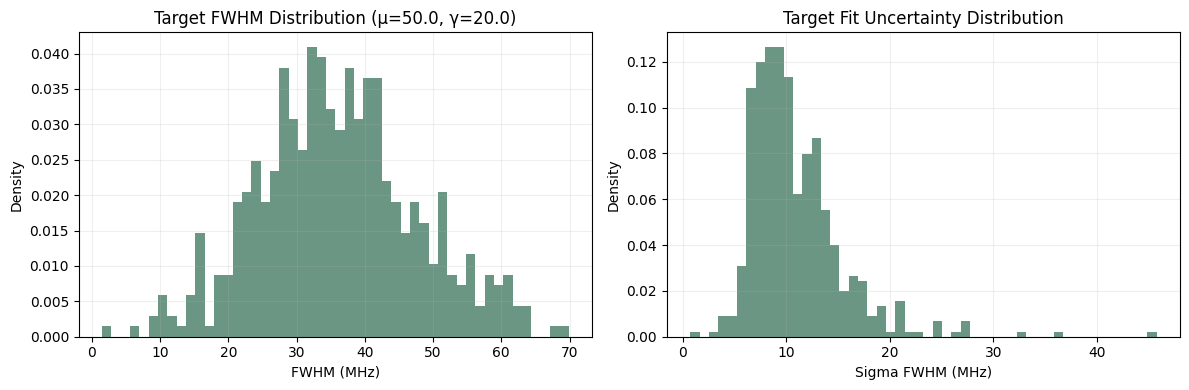

FWHM mean=36.1, sigma mean=10.9 (16s)


In [4]:
t_total = time.time()

print(f"Generating target ({N_TARGET} runs)...", end=" ", flush=True)
rng = np.random.default_rng(SEED)
target, target_sigmas = [], []
for ti in range(N_TARGET):
    if ti % 100 == 0:
        print(f'{ti}...', end=' ', flush=True)
    n = max(round(NBAR_TRUE + 6 * rng.standard_normal()), 0)
    u = rng.uniform(0, 1, size=n)
    bg = int(rng.poisson(LAMBDA_))
    b = rng.uniform(FREQ_MIN, FREQ_MAX, size=bg)
    fw, sig, _ = compute_fwhm_and_dgamma(GAMMA_TRUE, u, b)
    target.append(fw)
    target_sigmas.append(sig)
target_t = torch.tensor(target)
st, _ = torch.sort(target_t)
target_sigmas_t = torch.tensor(target_sigmas)
st_sig, _ = torch.sort(target_sigmas_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(target_t.numpy(), bins=50, density=True, alpha=0.7, color='#2d6a4f')
ax1.set_xlabel('FWHM (MHz)'); ax1.set_ylabel('Density')
ax1.set_title(f'Target FWHM Distribution (μ={NBAR_TRUE}, γ={GAMMA_TRUE})')
ax1.grid(alpha=0.2)
ax2.hist(target_sigmas_t.numpy(), bins=50, density=True, alpha=0.7, color='#2d6a4f')
ax2.set_xlabel('Sigma FWHM (MHz)'); ax2.set_ylabel('Density')
ax2.set_title('Target Fit Uncertainty Distribution')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"FWHM mean={target_t.mean():.1f}, sigma mean={target_sigmas_t.mean():.1f} ({time.time()-t_total:.0f}s)")

## Joint Optimization Loop

At each iteration:
1. Draw N_RUNS samples from N(μ, SIGMA_PROP) → round to integer n
2. For each n: run PLE scan, fit pseudo-Voigt, extract FWHM + σ_FWHM + dFWHM/dγ
3. Compute W₁ loss: |sorted(FWHM) − sorted(target_FWHM)| + λ·|sorted(σ) − sorted(target_σ)|
4. **μ update:** REINFORCE gradient (L − baseline)·∇_μ log P(n|μ)
5. **γ update:** implicit diff through the fit, combining FWHM + CRLB sigma gradients

In [5]:
mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
bl = 0.0
history = []

# Store intermediate FWHM distributions for plots
dist_history = []

print(f"μ_init={MU_INIT}, γ_init={GAMMA_INIT}, true=({NBAR_TRUE},{GAMMA_TRUE})")
print(f"N_ITER={N_ITER}, N_RUNS={N_RUNS}\n")

for step in range(N_ITER):
    rng2 = np.random.default_rng(SEED + step)
    fwhms, sigmas, dfs, dsigs, ns = [], [], [], [], []
    
    for _ in range(N_RUNS):
        n = max(round(mu_val + SIGMA_PROP * rng2.standard_normal()), 0)
        ns.append(n)
        u = rng2.uniform(0, 1, size=n)
        bg = int(rng2.poisson(LAMBDA_))
        b = rng2.uniform(FREQ_MIN, FREQ_MAX, size=bg)
        fw, sig, dg = compute_fwhm_and_dgamma(gamma_val, u, b)
        dsig = min(2.0 / math.sqrt(max(n, 1)), 2.0)  # CRLB: dσ/dγ ≈ 2/√n
        fwhms.append(fw); sigmas.append(sig)
        dfs.append(dg); dsigs.append(dsig)
    
    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    ds_t = torch.tensor(dsigs, dtype=torch.float32)
    
    sf, sidx = torch.sort(ft)
    pl = torch.abs(sf - st[:N_RUNS])
    nss = nt[sidx]; dgs = dg_t[sidx]; ds_s = ds_t[sidx]
    ss = si_t[sidx]
    
    loss_fwhm = pl.mean()
    pl_sig = torch.abs(ss - st_sig[:N_RUNS])
    loss_sigma = pl_sig.mean()
    mean_loss = (loss_fwhm + LAMBDA_SIGMA * loss_sigma).item()
    loss_fwhm_val = loss_fwhm.item(); loss_sigma_val = loss_sigma.item()
    
    if step == 0: bl = mean_loss
    else: bl = (1 - BASELINE_ALPHA) * bl + BASELINE_ALPHA * mean_loss
    
    # ---- MU gradient (REINFORCE) ----
    adv = (pl.detach() - bl).numpy()
    scores = (nss.numpy() - mu_val) / SIGMA_PROP**2
    raw_grad_mu = float(np.mean(adv * scores))
    grad_mu = max(min(raw_grad_mu, CLIP), -CLIP)
    mu_val += LR_MU * (-grad_mu)
    mu_val = max(1.0, min(200.0, mu_val))
    
    # ---- GAMMA gradient (implicit diff + CRLB sigma) ----
    signs_fw = torch.sign(sf - st[:N_RUNS])
    signs_sg = torch.sign(ss - st_sig[:N_RUNS])
    raw_grad_fwhm = float((signs_fw * dgs).mean().item())
    raw_grad_sigma = float((signs_sg * ds_s).mean().item())
    raw_grad_gamma = raw_grad_fwhm + LAMBDA_GAMMA * raw_grad_sigma
    grad_gamma = max(min(raw_grad_gamma, CLIP), -CLIP)
    gamma_val += LR_GAMMA * (-grad_gamma)
    gamma_val = max(0.1, min(100.0, gamma_val))
    
    rho = float(np.corrcoef(nss.numpy(), pl.numpy())[0, 1]) if pl.std() > 0.01 and nss.std() > 0.01 else 0.0
    
    info = {
        'step': step, 'mu': mu_val, 'gamma': gamma_val,
        'loss': mean_loss, 'loss_fwhm': loss_fwhm_val, 'loss_sigma': loss_sigma_val,
        'baseline': bl,
        'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
        'rho': rho, 'mean_n': float(np.mean(ns)),
        'mean_df': float(dg_t.mean().item()),
        'mean_dsig': float(ds_t.mean().item()),
        'mean_sigma': float(ss.mean().item()),
    }
    history.append(info)
    dist_history.append({'step': step, 'mu': mu_val, 'gamma': gamma_val, 'fwhms': list(np.array(fwhms))})
    
    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: μ={mu_val:6.2f}  γ={gamma_val:5.1f}  "
              f"L={mean_loss:.2f}  ∇μ={grad_mu:+.4f}  ∇γ={grad_gamma:+.4f}  "
              f"({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

μ_init=8.0, γ_init=5.0, true=(50.0,20.0)
N_ITER=80, N_RUNS=300



  S 0: μ=  8.15  γ=  6.5  L=22.02  ∇μ=-0.0097  ∇γ=-2.9547  (23s)


  S 5: μ= 13.84  γ= 11.8  L=13.83  ∇μ=-0.0682  ∇γ=-1.5982  (61s)


  S10: μ= 22.99  γ= 14.2  L=8.11  ∇μ=-0.1123  ∇γ=-0.5075  (101s)


  S15: μ= 31.58  γ= 15.3  L=6.08  ∇μ=-0.1945  ∇γ=-0.0478  (142s)


...

  S65: μ= 59.72  γ= 15.4  L=2.17  ∇μ=-0.0319  ∇γ=+0.9941  (572s)


  S70: μ= 61.55  γ= 16.1  L=2.08  ∇μ=-0.0263  ∇γ=+0.0592  (617s)


  S75: μ= 62.94  γ= 16.0  L=2.41  ∇μ=-0.0058  ∇γ=-0.1194  (663s)


  S79: μ= 63.96  γ= 15.9  L=2.14  ∇μ=-0.0190  ∇γ=+0.2194  (700s)



Done. 700s


## FWHM Distribution Convergence

Every 5 steps, comparing the current FWHM distribution to the target. Watch how the distribution shifts from the initial guess toward the target over the 80 iterations.

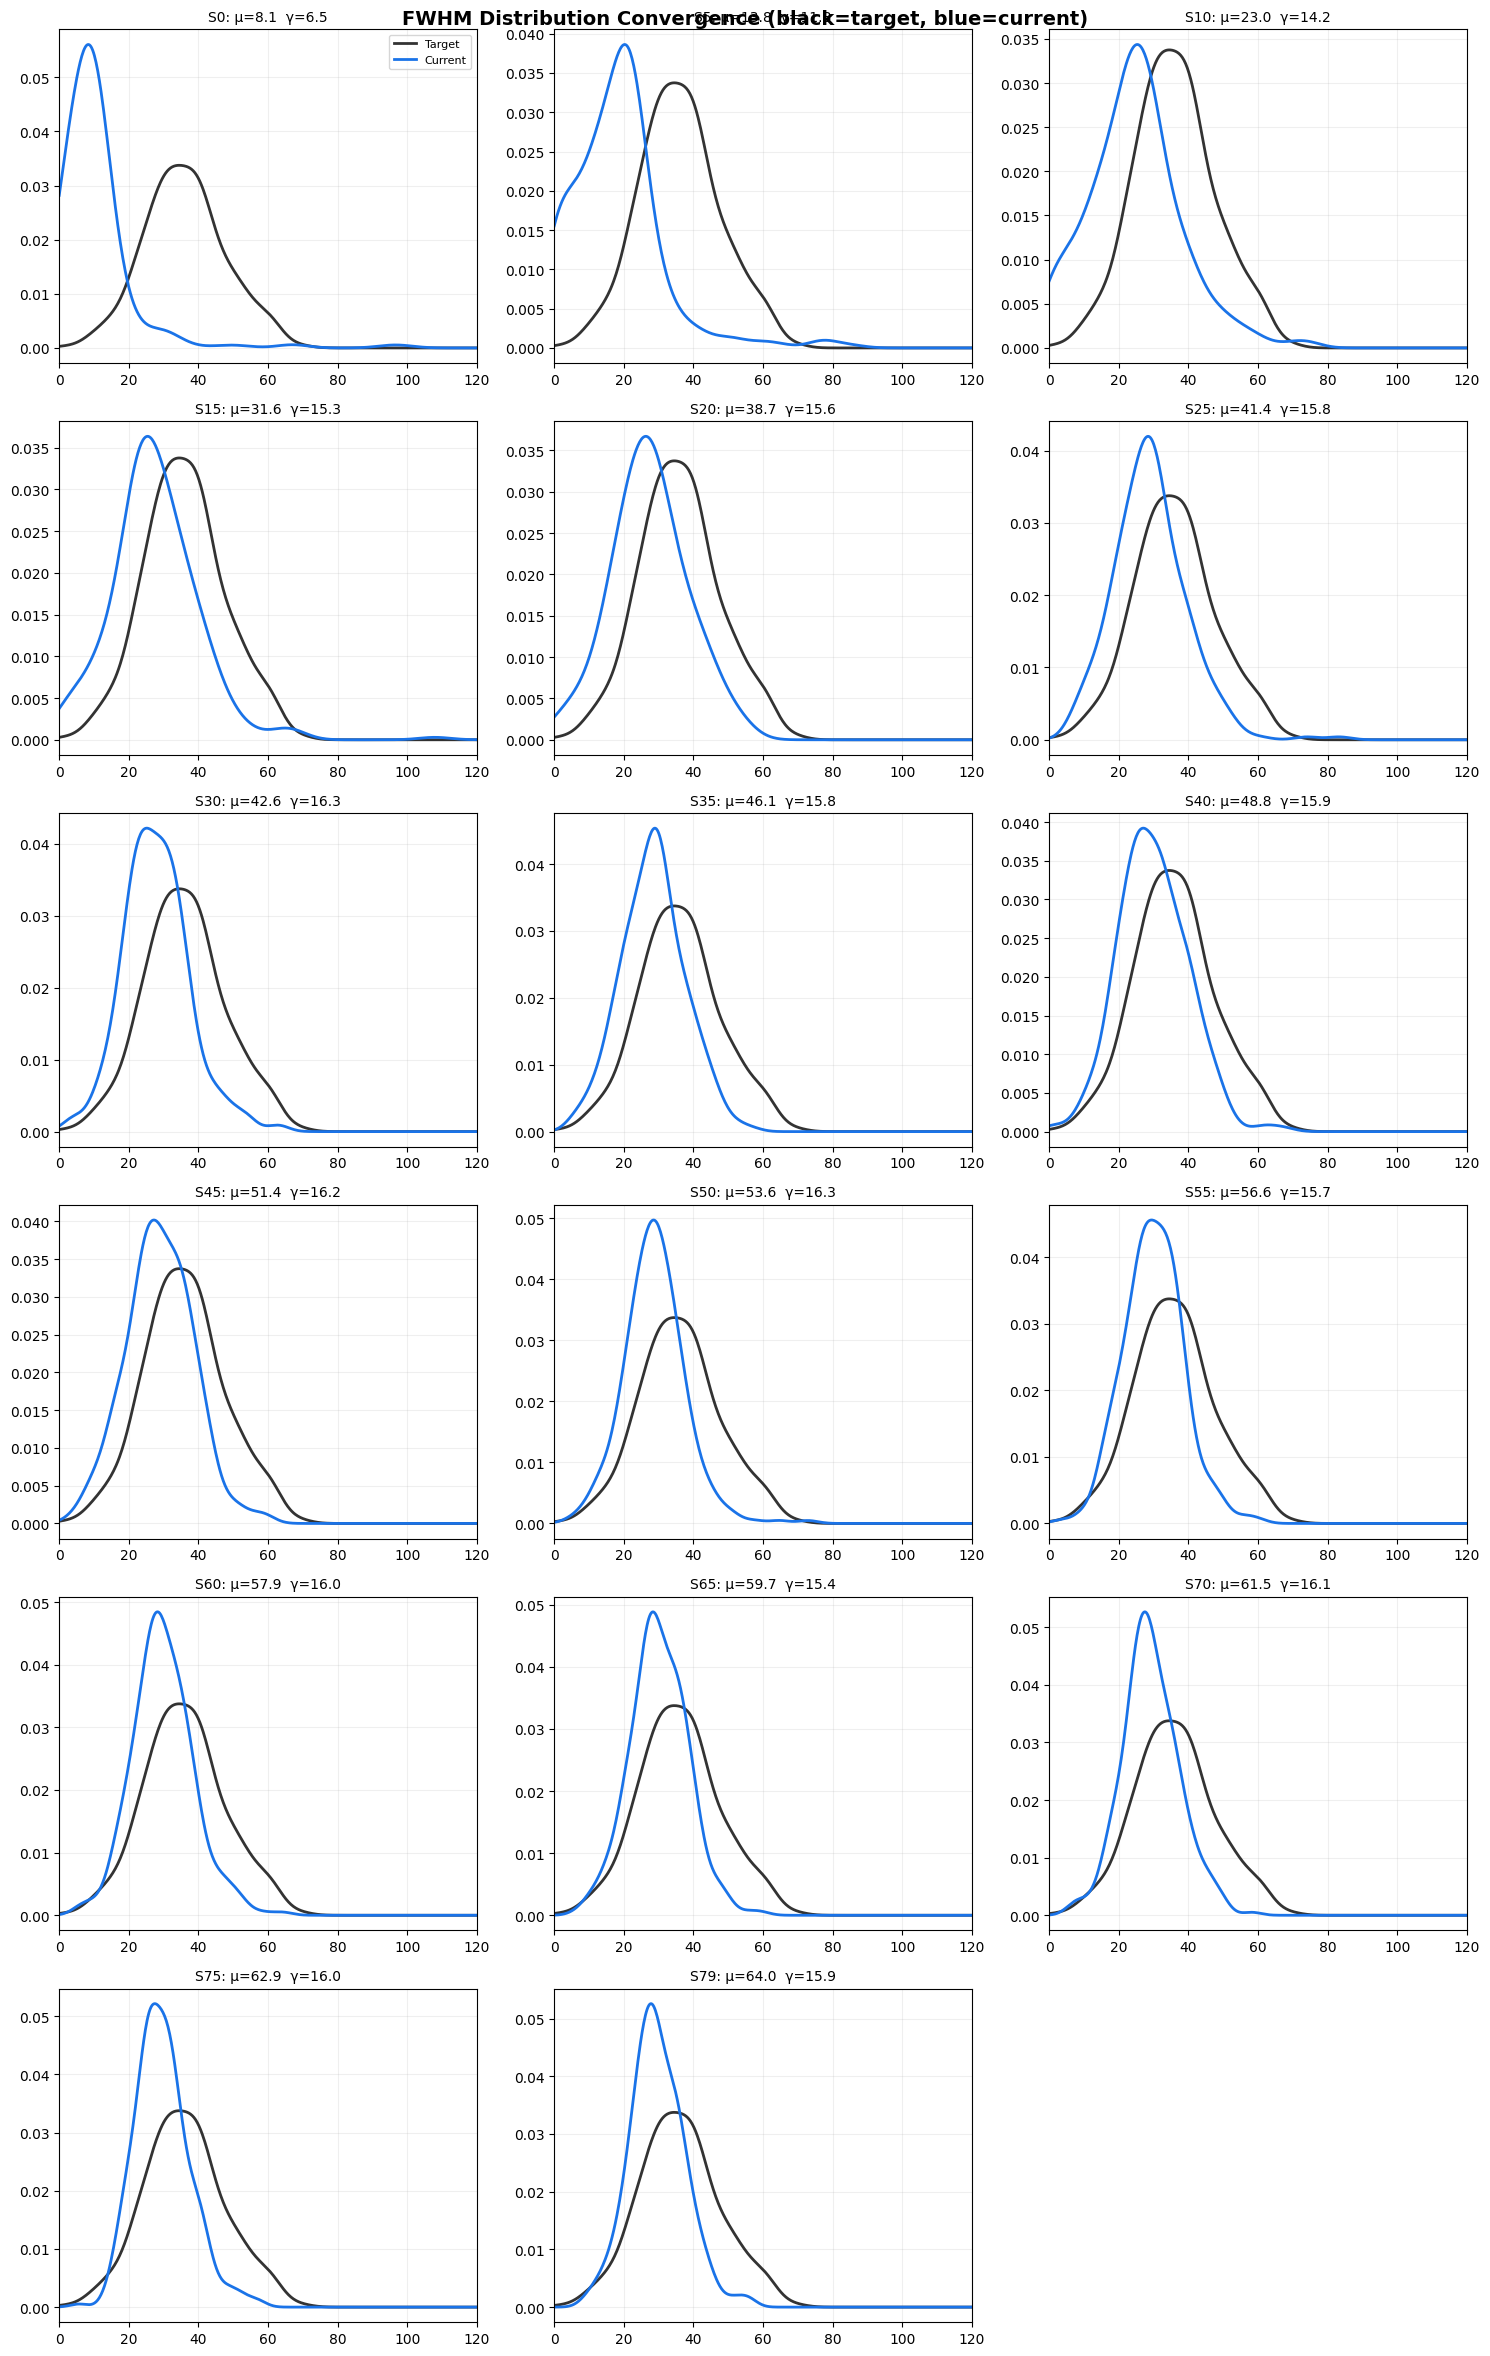

In [6]:
n_plots = len([d for d in dist_history if d['step'] % 5 == 0 or d['step'] == dist_history[-1]['step']])
cols = 3
rows = (n_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

xg = np.linspace(0, 120, 500)
kt = gaussian_kde(target_t.numpy())

idx = 0
for d in dist_history:
    if d['step'] % 5 != 0 and d['step'] != dist_history[-1]['step']:
        continue
    ax = axes[idx]
    kf = gaussian_kde(np.array(d['fwhms']))
    ax.plot(xg, kt(xg), 'k-', lw=2, label='Target', alpha=0.8)
    ax.plot(xg, kf(xg), '-', color='#1a73e8', lw=2, label='Current')
    ax.set_title(f"S{d['step']}: μ={d['mu']:.1f}  γ={d['gamma']:.1f}", fontsize=10)
    ax.set_xlim(0, 120)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=8)
    idx += 1

# Turn off unused axes
for i in range(idx, len(axes)):
    axes[i].axis('off')

fig.suptitle('FWHM Distribution Convergence (black=target, blue=current)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Optimization Trajectory: μ vs γ

The path from start (red) through each iteration (colored by step) to the end (blue), with the true point (green) shown. A well-converged run ends close to the green X.

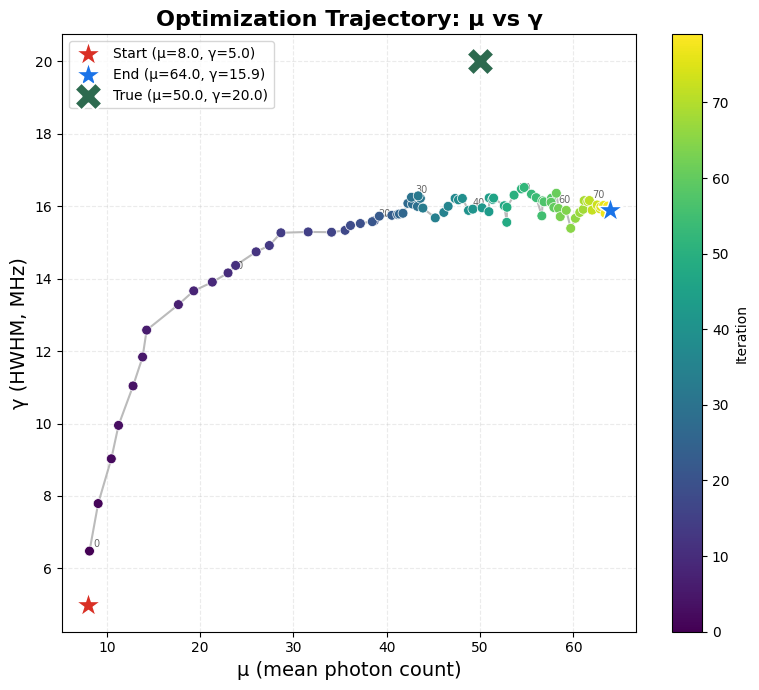

In [7]:
stp = [h['step'] for h in history]
mu_v = [h['mu'] for h in history]
ga_v = [h['gamma'] for h in history]
fm, fg = history[-1]['mu'], history[-1]['gamma']

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Path line
ax.plot(mu_v, ga_v, '-', color='#555', lw=1.5, alpha=0.4, zorder=1)
sc = ax.scatter(mu_v, ga_v, c=stp, cmap='viridis', s=50, zorder=5, edgecolors='white', lw=0.5)

# Start
ax.scatter(MU_INIT, GAMMA_INIT, s=350, marker='*', color='#d93025',
           zorder=10, label=f'Start (μ={MU_INIT}, γ={GAMMA_INIT})', edgecolors='white', linewidth=1)
# End
ax.scatter(fm, fg, s=350, marker='*', color='#1a73e8',
           zorder=10, label=f'End (μ={fm:.1f}, γ={fg:.1f})', edgecolors='white', linewidth=1)
# True
ax.scatter(NBAR_TRUE, GAMMA_TRUE, s=400, marker='X', color='#2d6a4f',
           zorder=10, label=f'True (μ={NBAR_TRUE}, γ={GAMMA_TRUE})', edgecolors='white', linewidth=1.5)

cbar = plt.colorbar(sc, ax=ax, label='Iteration')
ax.set_xlabel('μ (mean photon count)', fontsize=14)
ax.set_ylabel('γ (HWHM, MHz)', fontsize=14)
ax.set_title('Optimization Trajectory: μ vs γ', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.25, ls='--')

# Annotate some intermediate steps
for i in range(0, len(mu_v), max(1, len(mu_v)//8)):
    ax.annotate(str(stp[i]), (mu_v[i], ga_v[i]), textcoords="offset points",
                xytext=(3, 3), fontsize=7, alpha=0.6)

plt.tight_layout()
plt.show()

## Results Summary

In [8]:
print(f"{'='*60}")
print(f"  JOINT OPTIMIZATION (IMPLICIT DIFF + dSIGMA/dGAMMA)")
print(f"{'='*60}")
print(f"  μ:     {MU_INIT:.0f} → {fm:.2f}  (true={NBAR_TRUE})  error={abs(fm-NBAR_TRUE):.2f}")
print(f"  γ:     {GAMMA_INIT:.0f} → {fg:.2f}  (true={GAMMA_TRUE})  error={abs(fg-GAMMA_TRUE):.2f}")
print(f"  Loss:  {history[0]['loss']:.2f} → {history[-1]['loss']:.2f}")
print(f"  Time:  {time.time()-t_total:.0f}s")
print(f"{'='*60}")

  JOINT OPTIMIZATION (IMPLICIT DIFF + dSIGMA/dGAMMA)
  μ:     8 → 63.96  (true=50.0)  error=13.96
  γ:     5 → 15.90  (true=20.0)  error=4.10
  Loss:  22.02 → 2.14
  Time:  702s
